## **Exploratory Analysis: Clustering for a New Labeling Strategy**
This section will guide you through the initial steps of preparing your data for unsupervised learning (clustering) to identify patterns that could inform a new labeling strategy.

### **1. Setup and Imports**
First, we'll import the necessary libraries and configure logging.

In [23]:
# --- Imports (from previous cell, ensure these are at the top of your notebook) ---
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA # Import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from typing import Dict, Any, List, Optional, Tuple

# Add project root to Python path (assuming this notebook is run from project root or scripts folder)
PROJECT_ROOT = Path(__file__).resolve().parent.parent if '__file__' in locals() else Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

# Load environment variables (if you use a .env file for paths/configs)
from dotenv import load_dotenv
load_dotenv()

# Import configuration and utilities
try:
    from config.paths import PATHS
    from config.params import GENERAL_CONFIG, LABELING_CONFIG, STRATEGY_CONFIG, FEATURE_CONFIG # Import FEATURE_CONFIG
    from utils.data_manager import DataManager
except ImportError as e:
    print(f"CRITICAL ERROR: Failed to import necessary modules. Ensure your project structure and dependencies are correct. Error: {e}")
    sys.exit(1) # Exit if core imports fail

print("Starting exploratory analysis for clustering-based labeling strategy.")

# --- Define parameters for data loading (adjust as needed) ---
SYMBOL = 'ADAUSDT' # Example symbol, changed to ADAUSDT as you used it recently
INTERVAL = '5m'    # Example interval, changed to 5m as you used it recently

# --- PCA Parameters (New) ---
# You can adjust these based on your exploratory analysis
PCA_N_COMPONENTS = 0.95 # float (0-1) for variance explained, or int for number of components
                        # 0.95 means retain 95% of variance.

# --- Transaction Costs (NEW) ---
# Use values from STRATEGY_CONFIG for consistency
TRADING_FEE_RATE = STRATEGY_CONFIG.get('trading_fee_rate', 0.0005) # e.g., 0.0005 for 0.05%
SLIPPAGE_RATE = STRATEGY_CONFIG.get('slippage_tolerance_pct', 0.01) / 100.0 # e.g., 0.01 for 0.01% converted to fraction
print(f"Using trading fee rate: {TRADING_FEE_RATE:.4f}")
print(f"Using slippage rate: {SLIPPAGE_RATE:.4f}")

# --- OPTIMAL K (fixed for this optimization run) ---
# We will keep K=3 for this optimization, as decided previously.
OPTIMAL_K = 3

# --- FUTURE RETURN WINDOWS TO TEST (NEW) ---
FUTURE_RETURN_WINDOWS_TO_TEST = [20, 50, 80, 100, 150, 200]
print(f"Testing Future Return Windows: {FUTURE_RETURN_WINDOWS_TO_TEST}")

Starting exploratory analysis for clustering-based labeling strategy.
Using trading fee rate: 0.0005
Using slippage rate: 0.0001
Testing Future Return Windows: [20, 50, 80, 100, 150, 200]


### **2. Load Processed Data**
We'll use your DataManager to load the processed data, which should contain all your engineered features along with OHLCV data.

In [24]:
# --- Load Processed Data ---
dm = DataManager()

try:
    df_processed = dm.load_data(
        symbol=SYMBOL,
        interval=INTERVAL,
        data_type='processed'
    )
    print(f"Successfully loaded processed data for {SYMBOL} {INTERVAL}. Shape: {df_processed.shape}")
    print(f"\nDataFrame Head:\n{df_processed.head()}")
    print(f"\nDataFrame Info:\n")
    df_processed.info()
    print(f"\nDataFrame Description:\n{df_processed.describe()}")

except FileNotFoundError:
    print(f"CRITICAL ERROR: Processed data file not found for {SYMBOL} {INTERVAL}. "
          f"Please ensure you have run the feature engineering script first.")
    sys.exit(1)
except Exception as e:
    print(f"CRITICAL ERROR: Error loading processed data for {SYMBOL} {INTERVAL}: {e}")
    sys.exit(1)

# Basic validation
if df_processed.empty:
    print("CRITICAL ERROR: Loaded processed data is empty. Cannot proceed with analysis.")
    sys.exit(1)
if not isinstance(df_processed.index, pd.DatetimeIndex):
    print("CRITICAL ERROR: Loaded DataFrame does not have a DatetimeIndex. Please ensure your data processing pipeline sets the index correctly.")
    sys.exit(1)
if not all(col in df_processed.columns for col in ['open', 'high', 'low', 'close', 'volume']):
    print("CRITICAL ERROR: Loaded DataFrame is missing essential OHLCV columns (open, high, low, close, volume).")
    sys.exit(1)

print("Initial data loading and inspection complete.")

2025-07-29 19:05:14,432 - INFO - Attempting to load data (DataFrame) from c:\Users\dimit\Downloads\CryptoFuturesBot\data\processed\ADAUSDT_5m_processed.parquet
2025-07-29 19:05:14,703 - INFO - Successfully loaded data from c:\Users\dimit\Downloads\CryptoFuturesBot\data\processed\ADAUSDT_5m_processed.parquet. Shape: (139180, 126)


Successfully loaded processed data for ADAUSDT 5m. Shape: (139180, 126)

DataFrame Head:
                             open    high     low   close   volume  \
timestamp                                                            
2024-01-01 00:00:00+00:00  0.5941  0.5975  0.5932  0.5973  3778102   
2024-01-01 00:05:00+00:00  0.5972  0.5973  0.5958  0.5967  1656258   
2024-01-01 00:10:00+00:00  0.5967  0.5987  0.5964  0.5974  1899024   
2024-01-01 00:15:00+00:00  0.5974  0.5984  0.5960  0.5961  1924883   
2024-01-01 00:20:00+00:00  0.5961  0.5971  0.5954  0.5966  1470259   

                           log_returns  typical_price     atr_5  atr_14  \
timestamp                                                                 
2024-01-01 00:00:00+00:00          NaN            NaN  0.000000     0.0   
2024-01-01 00:05:00+00:00          NaN       0.596000  0.000000     0.0   
2024-01-01 00:10:00+00:00    -0.001005       0.596600  0.000000     0.0   
2024-01-01 00:15:00+00:00     0.001172       

### **3. Feature Selection and Preprocessing for Clustering**

In [25]:
# --- Feature Selection and Preprocessing for Clustering (with PCA) - Now a function ---

from typing import Union


def prepare_features_and_returns(df: pd.DataFrame, future_return_window: int,
                                 trading_fee_rate: float, slippage_rate: float,
                                 pca_n_components: Union[float, int],
                                 general_config: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    """
    Prepares features for clustering (scaling, PCA) and calculates net future returns.

    Args:
        df (pd.DataFrame): The input DataFrame with OHLCV and engineered features.
        future_return_window (int): The number of bars forward for return calculation.
        trading_fee_rate (float): The trading fee rate as a fraction.
        slippage_rate (float): The slippage rate as a fraction.
        pca_n_components (Union[float, int]): PCA components (variance explained or number).
        general_config (Dict[str, Any]): General configuration for random_seed.

    Returns:
        Tuple[pd.DataFrame, pd.Series, List[str]]:
            - X_for_clustering_final: DataFrame with PCA-transformed features.
            - future_returns_final: Series with calculated net future returns.
            - pca_component_names: List of names for PCA components.
    """
    # Get all numeric columns that are NOT part of the raw OHLCV data.
    EXCLUDE_COLS_FOR_FEATURES = ['open', 'high', 'low', 'close', 'volume', 'open_time', 'vol_adj', 'label']
    all_numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    features_for_clustering_list = [col for col in all_numeric_cols if col not in EXCLUDE_COLS_FOR_FEATURES]

    if not features_for_clustering_list:
        print("CRITICAL ERROR: No numeric features identified for clustering after excluding OHLCV and other known columns. Please check your data.")
        return pd.DataFrame(), pd.Series(), []

    # --- Handle NaNs in Features ---
    df_features_for_pca = df[features_for_clustering_list].copy()
    df_features_for_pca.dropna(inplace=True)
    df_aligned_for_clustering = df.loc[df_features_for_pca.index].copy()

    if df_features_for_pca.empty:
        print("CRITICAL ERROR: DataFrame for PCA is empty after dropping NaNs. Cannot proceed.")
        return pd.DataFrame(), pd.Series(), []

    # --- Feature Scaling (Pre-PCA) ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features_for_pca)
    X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering_list, index=df_features_for_pca.index)

    # --- Apply PCA for Dimensionality Reduction ---
    pca = PCA(n_components=pca_n_components, random_state=general_config.get('random_seed', 42))
    X_pca = pca.fit_transform(X_scaled_df)

    pca_component_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    X_pca_df = pd.DataFrame(X_pca, columns=pca_component_names, index=X_scaled_df.index)

    # --- Calculate NET Future Returns for Cluster Interpretation ---
    df_aligned_for_clustering['future_close'] = df_aligned_for_clustering['close'].shift(-future_return_window)

    entry_cost_long_factor = (1 + trading_fee_rate + slippage_rate)
    exit_revenue_long_factor = (1 - trading_fee_rate - slippage_rate)

    entry_revenue_short_factor = (1 - trading_fee_rate - slippage_rate)
    exit_cost_short_factor = (1 + trading_fee_rate + slippage_rate)

    safe_current_close = df_aligned_for_clustering['close'].replace(0, np.nan)

    df_aligned_for_clustering['net_return_long_potential'] = (
        (df_aligned_for_clustering['future_close'] * exit_revenue_long_factor - safe_current_close * entry_cost_long_factor) /
        (safe_current_close * entry_cost_long_factor)
    ) * 100.0

    df_aligned_for_clustering['net_return_short_potential'] = (
        (safe_current_close * entry_revenue_short_factor - df_aligned_for_clustering['future_close'] * exit_cost_short_factor) /
        (safe_current_close * entry_revenue_short_factor)
    ) * 100.0

    df_aligned_for_clustering['net_future_return_pct'] = np.where(
        df_aligned_for_clustering['net_return_long_potential'] > df_aligned_for_clustering['net_return_short_potential'],
        df_aligned_for_clustering['net_return_long_potential'],
        -df_aligned_for_clustering['net_return_short_potential'] # Invert short potential to reflect price movement direction
    )

    df_aligned_for_clustering.dropna(subset=['net_future_return_pct'], inplace=True)

    common_index_for_analysis = X_pca_df.index.intersection(df_aligned_for_clustering.index)
    X_for_clustering_final = X_pca_df.loc[common_index_for_analysis].copy()
    future_returns_final = df_aligned_for_clustering.loc[common_index_for_analysis, 'net_future_return_pct'].copy()

    if X_for_clustering_final.empty or future_returns_final.empty:
        print("CRITICAL ERROR: Data for clustering and future return calculation is empty after alignment and NaN removal.")
        return pd.DataFrame(), pd.Series(), []

    return X_for_clustering_final, future_returns_final, pca_component_names

## **Exploratory Analysis: Determining K and Clustering**
### **4. Determine Optimal Number of Clusters (K)**
We'll use two common methods: the Elbow Method and the Silhouette Score.

In [26]:
# --- Determine Optimal K: Elbow Method and Silhouette Score ---

# Define a range of K values to test
K_RANGE = range(2, 11) # Test K from 2 to 10 clusters

# This section will be run inside the loop for each FUTURE_RETURN_WINDOW.
# We'll re-evaluate the best K based on the combined analysis of all windows.
# For now, we keep OPTIMAL_K fixed at 3 for the detailed cluster interpretation.

### **5. Apply K-Means Clustering with Chosen K**
Based on the plots above, you'll need to decide on an optimal $K$. For this example, let's assume you choose $K=3$ (a common starting point for ternary classification). You can change $OPTIMAL_K$ to your preferred value.

In [27]:
# This section will be run inside the loop for each FUTURE_RETURN_WINDOW.

### **6. Interpret Clusters and Derive Labels**
Now, we'll analyze the median future return for each cluster. This will inform how we map each cluster to a trading label $(-1, 0, 1)$.


Analyzing for FUTURE_RETURN_WINDOW = 20 bars

Applying K-Means clustering with OPTIMAL_K = 3...


2025-07-29 19:05:18,081 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    52738
1    51505
2    34629
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 20:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52738  0.014122  0.006242  1.457120 -0.381925  0.419351 -1.545186  1.511712       50.669347
1        51505  0.029227 -0.010769  1.064075 -0.387347  0.373466 -1.352282  1.534230       48.735074
2        34629 -0.022641 -0.024898  1.810028 -0.779784  0.726083 -2.653911  2.656774       48.392965


C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:18,246 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


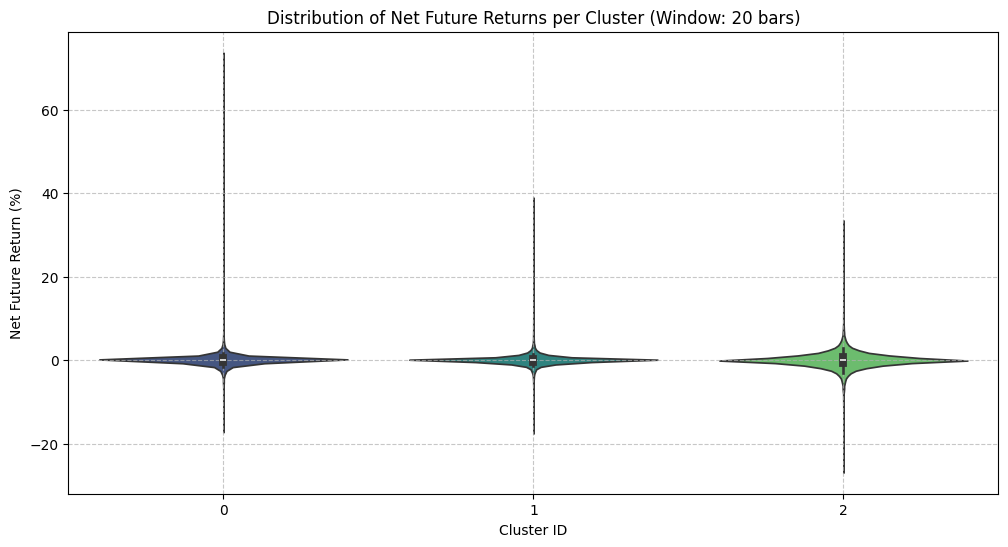


Median Feature Values per Cluster (PCA Components) for Window 20:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0       -3.936868 -3.200664  0.081034 -0.036659  0.382235 -0.354335  0.121865 -0.357081  0.041120  0.241469  0.173400 -0.050711 -0.004416 -0.115774 -0.055783 -0.132119  0.021950 -0.004362 -0.017679 -0.000158  0.035760  0.113641 -0.079207

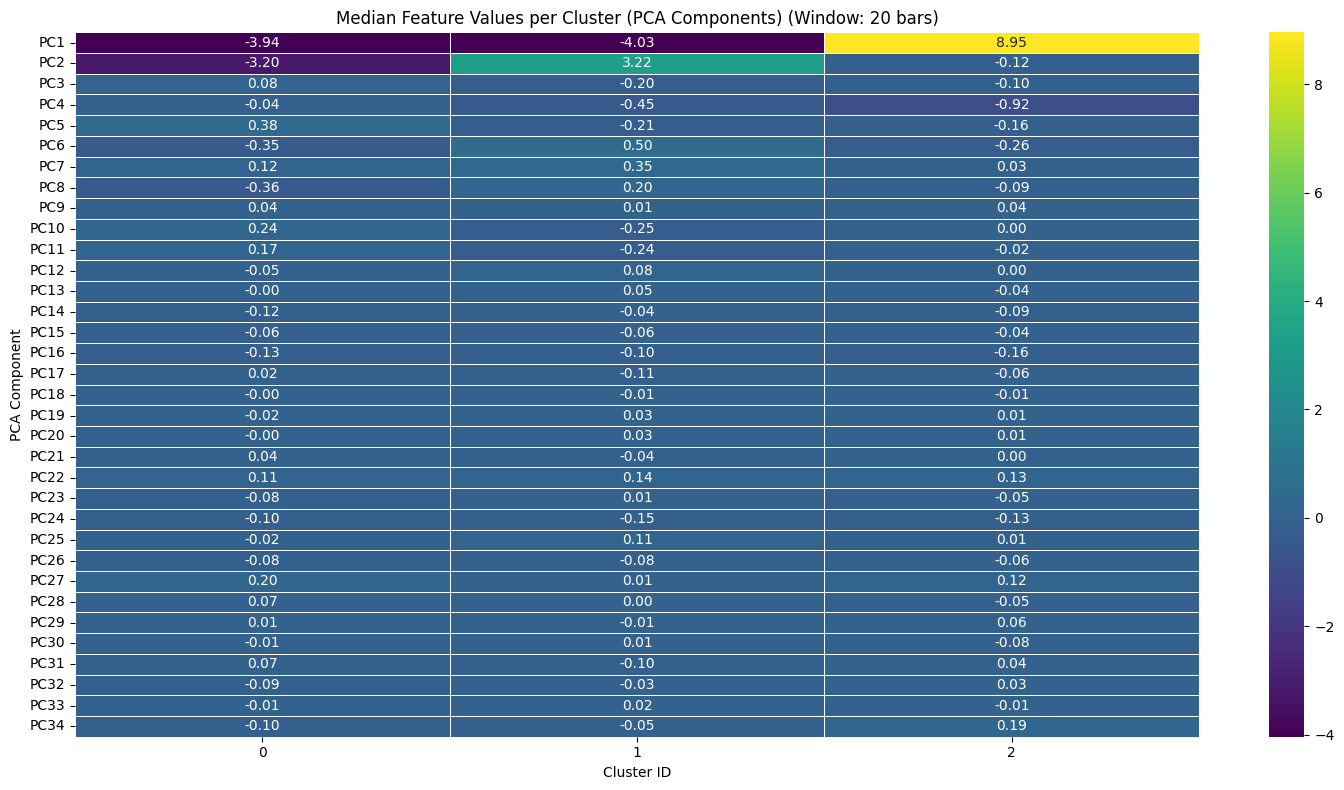


Analyzing for FUTURE_RETURN_WINDOW = 50 bars

Applying K-Means clustering with OPTIMAL_K = 3...
Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    52703
1    51456
2    34683
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 50:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52703  0.065337  0.018355  2.364006 -0.651269  0.733576 -2.483750  2.578844       51.203916
1        51456  0.053317 -0.020172  1.784979 -0.731289  0.673153 -2.377615  2.704966       48.557991
2        34683 -0.063136 -0.050644  2.784120 -1.318842  1.176721 -4.345322  4.348117       47.810166


2025-07-29 19:05:27,291 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:27,579 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


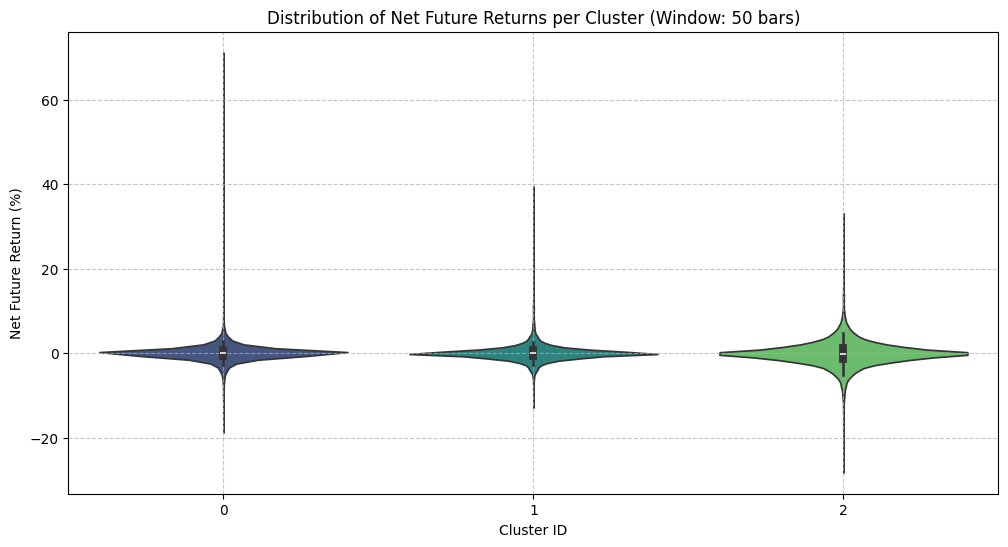


Median Feature Values per Cluster (PCA Components) for Window 50:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0       -3.941171 -3.200825  0.080210 -0.035657  0.382265 -0.354798  0.121913 -0.357164  0.040963  0.241518  0.173348 -0.050575 -0.004755 -0.115742 -0.055524 -0.132385  0.021930 -0.004368 -0.017678 -0.000153  0.035737  0.113641 -0.079310

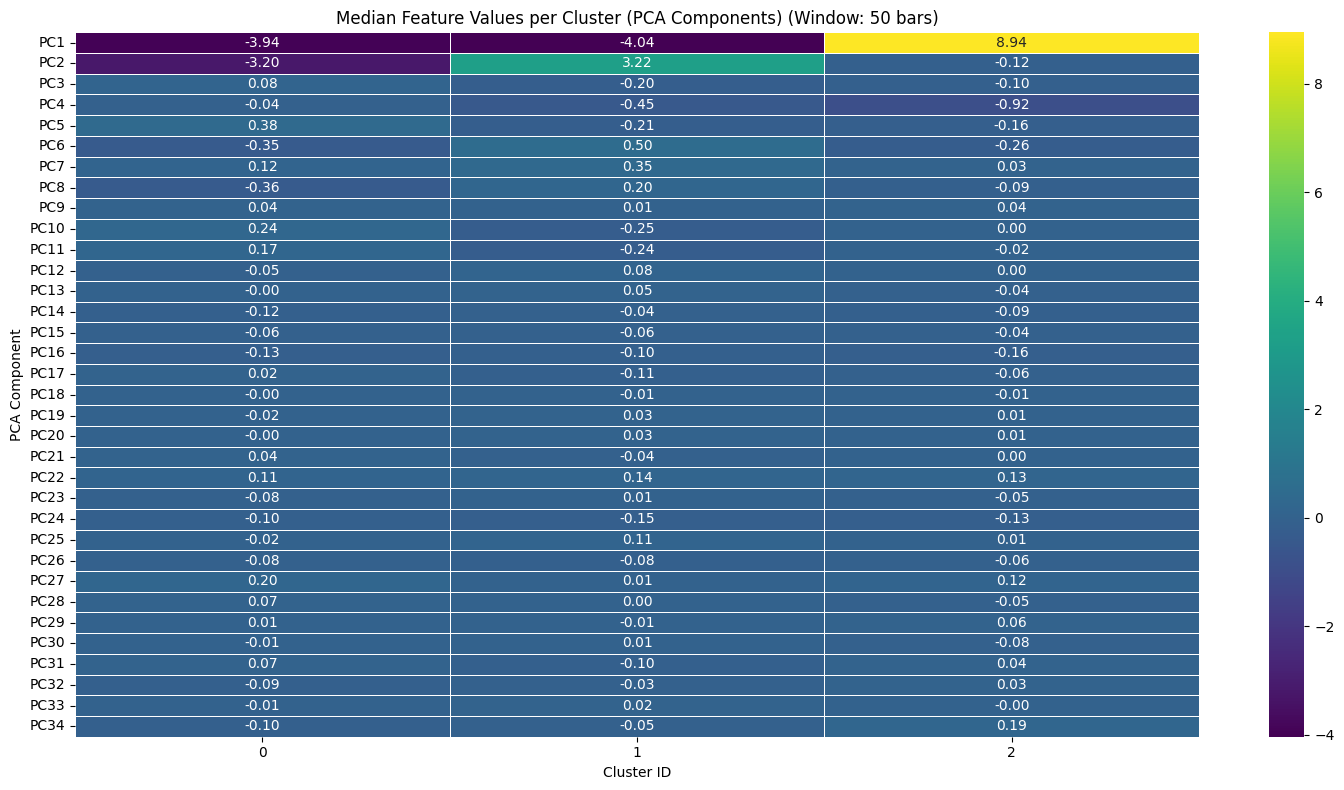


Analyzing for FUTURE_RETURN_WINDOW = 80 bars

Applying K-Means clustering with OPTIMAL_K = 3...
Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    34728
1    51332
2    52752
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 80:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
2        52752  0.108222  0.006144  2.890817 -0.881129  0.974325 -3.015874  3.398095       50.327950
1        51332  0.081306 -0.033768  2.512349 -0.995442  0.902309 -3.088528  3.565669       48.215538
0        34728 -0.092001 -0.063941  3.499383 -1.688871  1.423883 -5.550303  5.658789       47.920986


2025-07-29 19:05:35,430 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:35,577 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


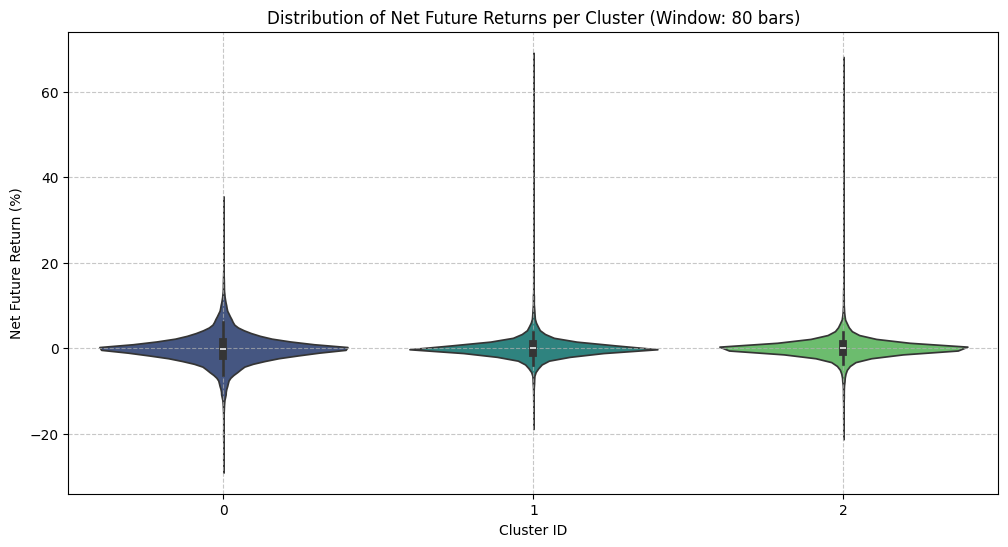


Median Feature Values per Cluster (PCA Components) for Window 80:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0        8.936331 -0.126028 -0.101296 -0.925552 -0.160434 -0.259156  0.029036 -0.093273  0.036161  0.003741 -0.020104  0.002093 -0.038041 -0.091752 -0.035331 -0.164686 -0.057264 -0.014171  0.006810  0.013707  0.002986  0.134018 -0.052575

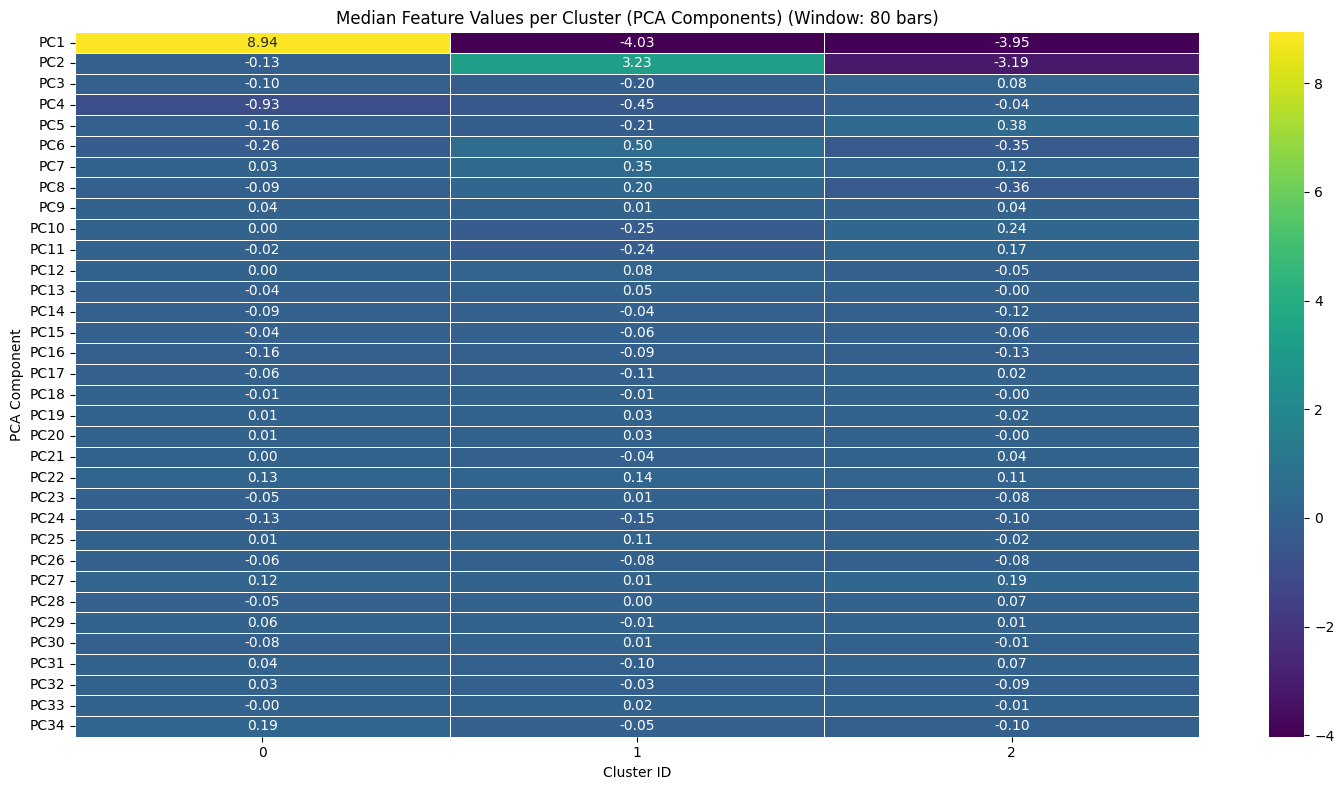


Analyzing for FUTURE_RETURN_WINDOW = 100 bars

Applying K-Means clustering with OPTIMAL_K = 3...
Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    52788
1    51410
2    34594
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 100:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52788  0.133615 -0.000616  3.324034 -1.048865  1.101566 -3.407696  3.927681       49.969690
1        51410  0.099931 -0.033222  2.795386 -1.126048  1.052885 -3.421527  3.985061       48.515853
2        34594 -0.107999 -0.081711  3.904136 -1.917389  1.616194 -6.243247  6.440484       47.701914


2025-07-29 19:05:41,847 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:42,002 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


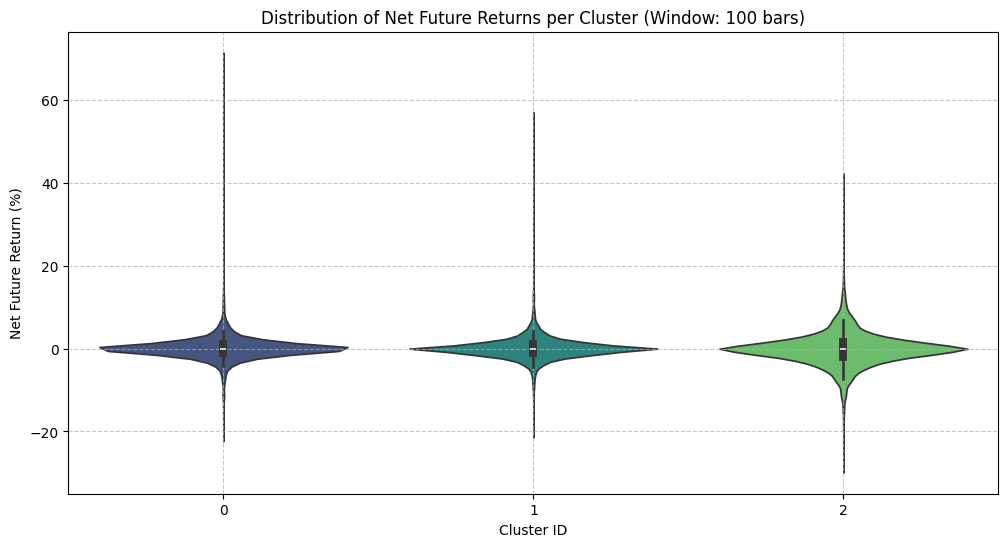


Median Feature Values per Cluster (PCA Components) for Window 100:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0       -3.948338 -3.190543  0.077508 -0.036161  0.382726 -0.352382  0.121145 -0.356537  0.040037  0.242275  0.172124 -0.049468 -0.004826 -0.115471 -0.055739 -0.132988  0.021694 -0.004313 -0.017633 -0.000155  0.035475  0.113831 -0.07920

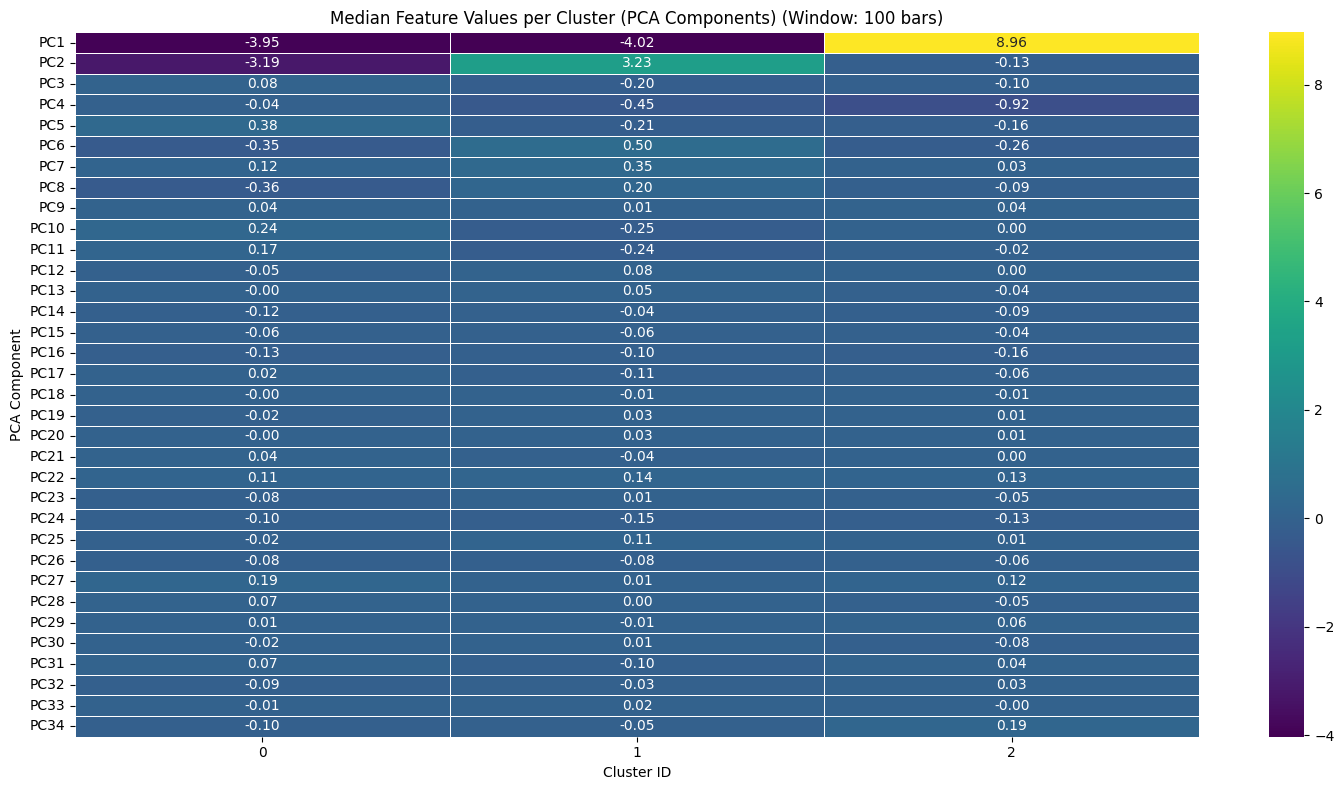


Analyzing for FUTURE_RETURN_WINDOW = 150 bars

Applying K-Means clustering with OPTIMAL_K = 3...


2025-07-29 19:05:48,212 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    52719
1    51327
2    34696
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 150:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52719  0.176321  0.010908  4.032055 -1.389606  1.420021 -4.160938  4.943086       50.439121
1        51327  0.172993 -0.050117  3.622311 -1.482984  1.381986 -4.156476  4.918550       48.212442
2        34696 -0.155642 -0.160342  4.719761 -2.556243  1.938281 -7.283084  7.602377       46.679733


C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:48,380 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


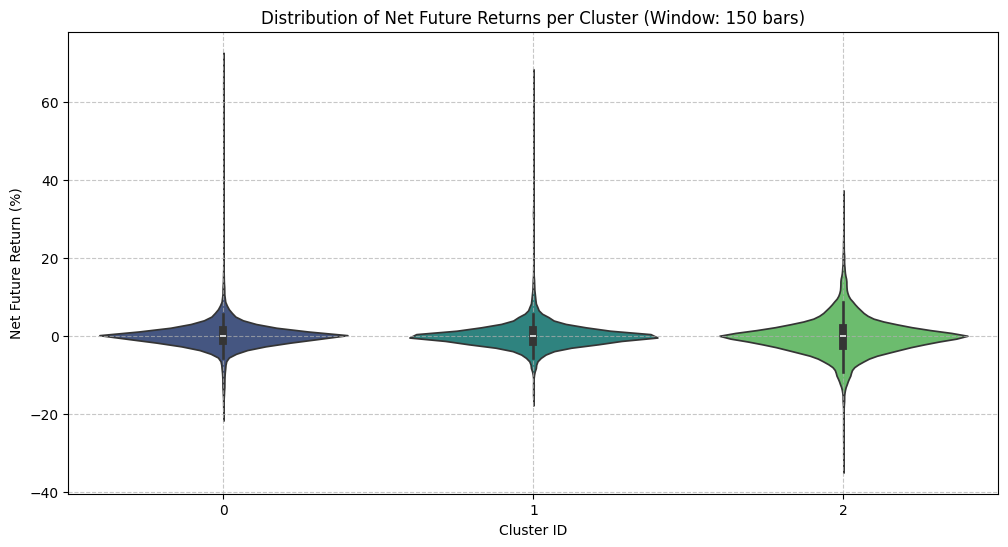


Median Feature Values per Cluster (PCA Components) for Window 150:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0       -3.951921 -3.193573  0.075967 -0.034907  0.382361 -0.352619  0.121252 -0.356967  0.040295  0.242703  0.172527 -0.049026 -0.004952 -0.115712 -0.055335 -0.132654  0.021863 -0.004295 -0.017633 -0.000175  0.035480  0.113740 -0.07929

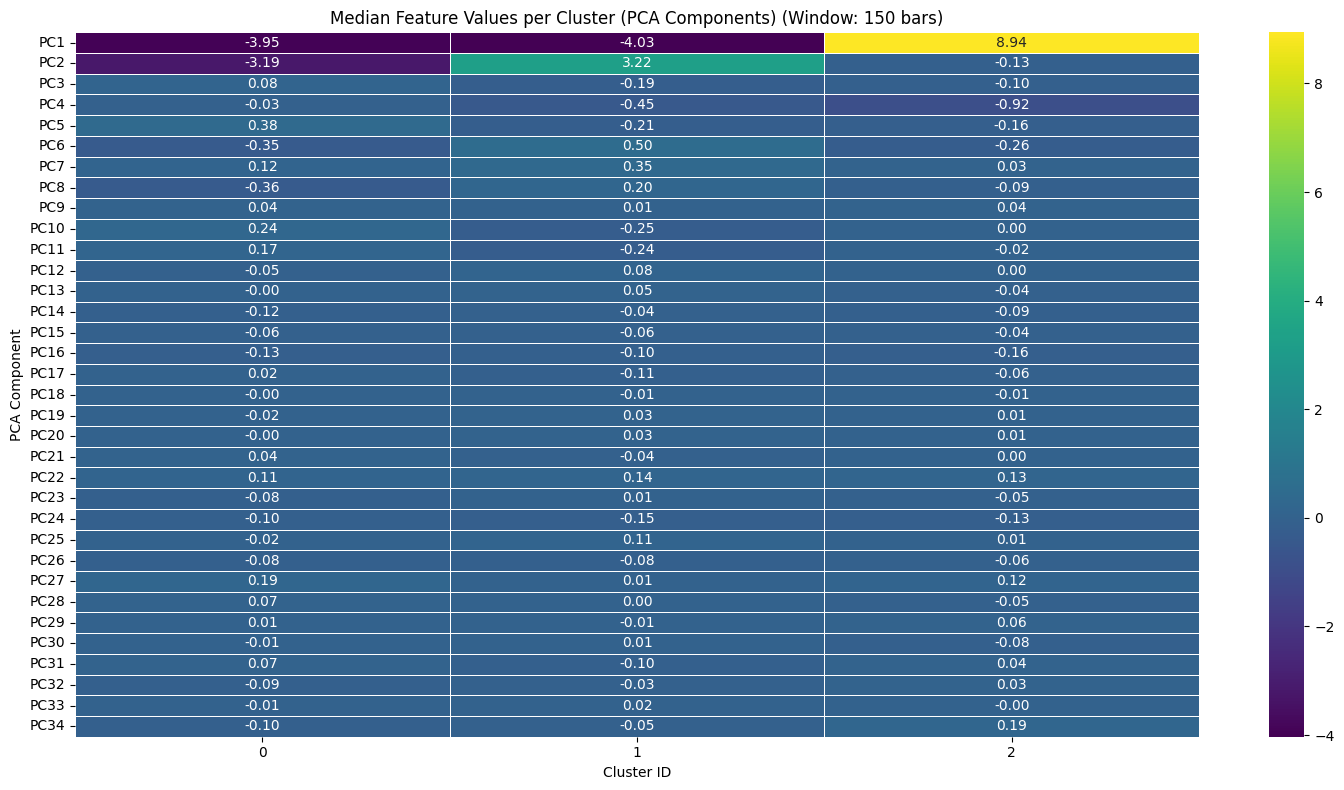


Analyzing for FUTURE_RETURN_WINDOW = 200 bars

Applying K-Means clustering with OPTIMAL_K = 3...
Clustering complete. Cluster labels added to data.

Cluster distribution:
cluster
0    51347
1    34667
2    52678
Name: count, dtype: int64

--- Enhanced Analysis of Net Future Returns per Cluster ---

Cluster Return Statistics (Net Future Return %) for Window 200:
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
2        52678  0.236114 -0.008792  4.491917 -1.636420  1.709497 -4.716357  5.640176       49.690573
0        51347  0.239869 -0.033038  4.382347 -1.755086  1.620964 -4.711222  5.571866       48.953201
1        34667 -0.224493 -0.282718  5.423335 -3.088205  2.241401 -8.251206  8.617451       45.616869


2025-07-29 19:05:56,390 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\dimit\AppData\Local\Temp\ipykernel_19052\488877937.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
2025-07-29 19:05:56,565 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


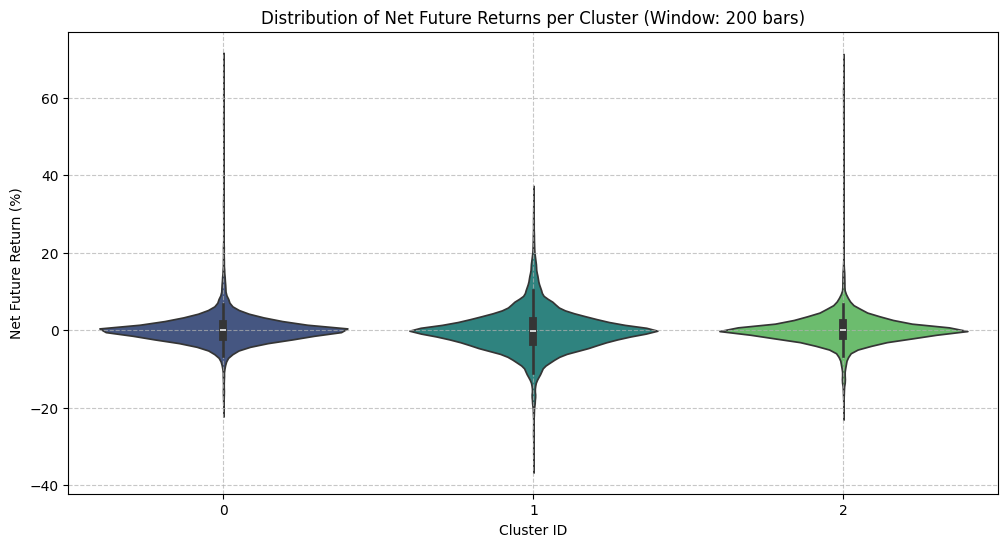


Median Feature Values per Cluster (PCA Components) for Window 200:
              PC1       PC2       PC3       PC4       PC5       PC6       PC7       PC8       PC9      PC10      PC11      PC12      PC13      PC14      PC15      PC16      PC17      PC18      PC19      PC20      PC21      PC22      PC23      PC24      PC25      PC26      PC27      PC28      PC29      PC30      PC31      PC32      PC33      PC34
cluster                                                                                                                                                                                                                                                                                                                                                    
0       -4.036572  3.223851 -0.193343 -0.444943 -0.207461  0.502195  0.353795  0.204764  0.008813 -0.245795 -0.243043  0.078684  0.052575 -0.035308 -0.055356 -0.095554 -0.108562 -0.007331  0.025366  0.030831 -0.044290  0.141400  0.01109

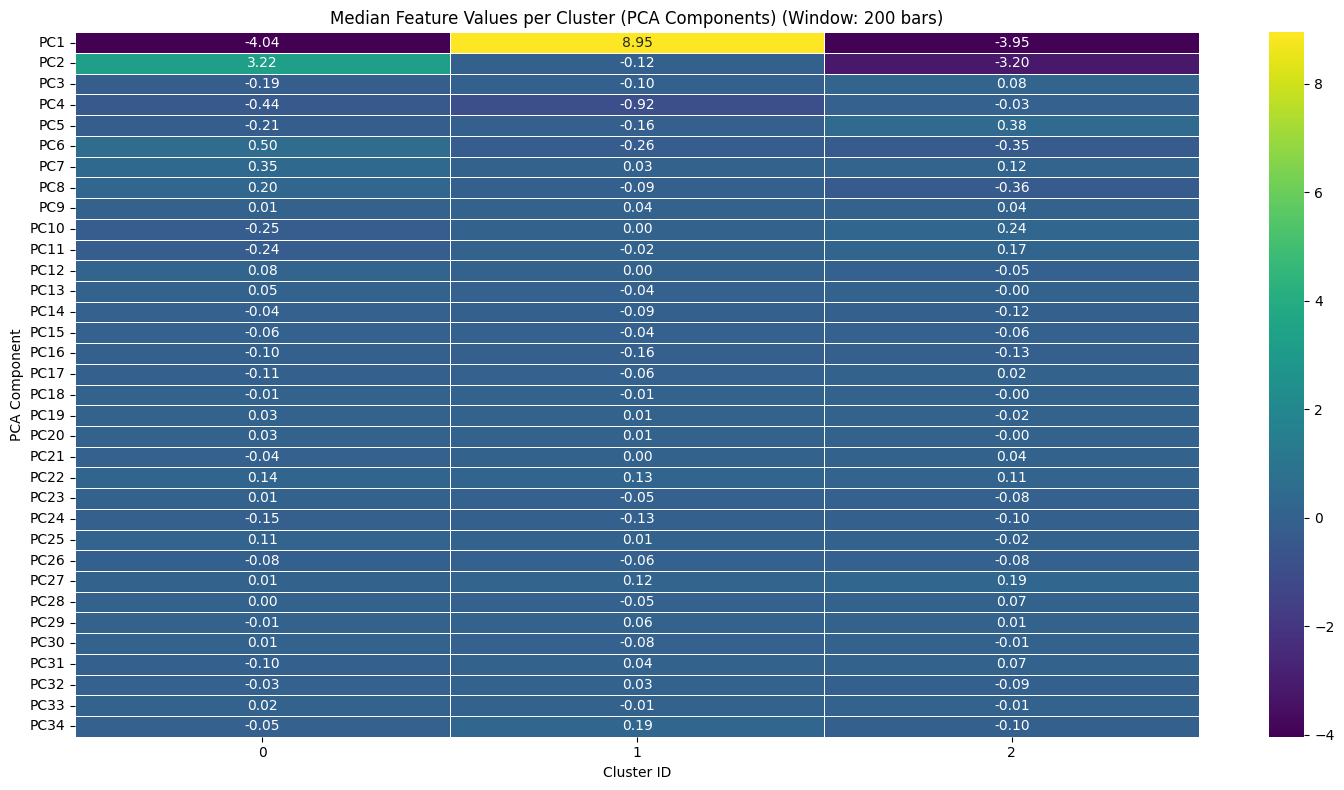



--- Summary of Cluster Statistics Across All Windows ---

Window: 20 bars
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52738  0.014122  0.006242  1.457120 -0.381925  0.419351 -1.545186  1.511712       50.669347
1        51505  0.029227 -0.010769  1.064075 -0.387347  0.373466 -1.352282  1.534230       48.735074
2        34629 -0.022641 -0.024898  1.810028 -0.779784  0.726083 -2.653911  2.656774       48.392965

Window: 50 bars
         count      mean    median       std       q25       q75       q05       q95  profitable_pct
cluster                                                                                             
0        52703  0.065337  0.018355  2.364006 -0.651269  0.733576 -2.483750  2.578844       51.203916
1        51456  0.053317 -0.020172  1.784979 -0.731289  0.673153 -2.377615  2.704966       48.55799

In [28]:
# --- Interpret Clusters: Enhanced Analysis of Net Future Returns (Looping through windows) ---

all_window_stats = {} # To store stats for each window

for window in FUTURE_RETURN_WINDOWS_TO_TEST:
    print(f"\n{'='*80}")
    print(f"Analyzing for FUTURE_RETURN_WINDOW = {window} bars")
    print(f"{'='*80}")

    # Prepare features and returns for the current window
    X_for_clustering_final, future_returns_final, pca_component_names = prepare_features_and_returns(
        df=df_processed,
        future_return_window=window,
        trading_fee_rate=TRADING_FEE_RATE,
        slippage_rate=SLIPPAGE_RATE,
        pca_n_components=PCA_N_COMPONENTS,
        general_config=GENERAL_CONFIG
    )

    if X_for_clustering_final.empty:
        print(f"Skipping window {window} due to empty data after preprocessing.")
        continue

    # Apply K-Means Clustering with the chosen OPTIMAL_K
    print(f"\nApplying K-Means clustering with OPTIMAL_K = {OPTIMAL_K}...")
    kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=GENERAL_CONFIG.get('random_seed', 42), n_init=10)
    cluster_labels = kmeans_final.fit_predict(X_for_clustering_final)

    # Add cluster labels to our aligned DataFrame for easier analysis
    future_returns_final_with_clusters = pd.DataFrame({
        'future_return_pct': future_returns_final,
        'cluster': cluster_labels
    }, index=future_returns_final.index)

    print("Clustering complete. Cluster labels added to data.")
    print(f"\nCluster distribution:\n{future_returns_final_with_clusters['cluster'].value_counts().sort_index()}")

    print("\n--- Enhanced Analysis of Net Future Returns per Cluster ---")

    # Calculate various statistics for each cluster
    cluster_return_stats = future_returns_final_with_clusters.groupby('cluster')['future_return_pct'].agg(
        count='size',
        mean='mean',
        median='median',
        std='std',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        q05=lambda x: x.quantile(0.05), # 5th percentile
        q95=lambda x: x.quantile(0.95), # 95th percentile
        profitable_pct=lambda x: (x > 0).mean() * 100 # Percentage of positive returns
    ).sort_values(by='median', ascending=False)

    print(f"\nCluster Return Statistics (Net Future Return %) for Window {window}:")
    print(cluster_return_stats.to_string()) # Use to_string() to prevent truncation

    all_window_stats[window] = cluster_return_stats # Store stats for comparison

    # --- Visualize Distribution of Returns per Cluster ---
    plt.figure(figsize=(12, 6))
    sns.violinplot(x='cluster', y='future_return_pct', data=future_returns_final_with_clusters, palette='viridis')
    plt.title(f'Distribution of Net Future Returns per Cluster (Window: {window} bars)')
    plt.xlabel('Cluster ID')
    plt.ylabel('Net Future Return (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # --- Characterize Clusters by Feature Medians (Optional but Recommended) ---
    # Merge cluster labels back to the PCA features for characterization
    X_for_clustering_final_with_cluster = X_for_clustering_final.copy()
    X_for_clustering_final_with_cluster['cluster'] = cluster_labels
    median_features_per_cluster = X_for_clustering_final_with_cluster.groupby('cluster')[pca_component_names].median()

    print(f"\nMedian Feature Values per Cluster (PCA Components) for Window {window}:")
    print(median_features_per_cluster.to_string())

    # --- Visualize Feature Medians per Cluster (Optional) ---
    plt.figure(figsize=(15, 8))
    sns.heatmap(median_features_per_cluster.T, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
    plt.title(f'Median Feature Values per Cluster (PCA Components) (Window: {window} bars)')
    plt.xlabel('Cluster ID')
    plt.ylabel('PCA Component')
    plt.tight_layout()
    plt.show()

print("\n\n--- Summary of Cluster Statistics Across All Windows ---")
for window, stats in all_window_stats.items():
    print(f"\nWindow: {window} bars")
    print(stats.to_string())

print("\nBased on these results, identify the `FUTURE_RETURN_WINDOW` that provides the best separation and highest profitability for your 'buy' and 'sell' clusters, while ideally having a 'neutral' cluster with profitability near 50%.")
print("Then, based on the chosen window's statistics, finalize your `CLUSTER_TO_LABEL_MAPPING`.")